In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
label_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")
label_df.rename(columns = {"m6A_level": "dom_label"}, inplace = True)

In [3]:
dorado_alt = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl")
dorado_alt.rename(columns = {"dom": "pred_dorado", "count_dom": "dorado_count"}, inplace = True)
dorado_alt = dorado_alt[["pred_dorado", "dorado_count", "genome_id"]]
print(dorado_alt)

                 pred_dorado  dorado_count        genome_id
genome_id                                                  
chr10:+:1000680     0.142857             7  chr10:+:1000680
chr10:+:1000681     0.004219           474  chr10:+:1000681
chr10:+:1000683     0.004073           491  chr10:+:1000683
chr10:+:1000685     0.017167           466  chr10:+:1000685
chr10:+:1000688     1.000000             1  chr10:+:1000688
...                      ...           ...              ...
chrX:-:9760794      0.000000             5   chrX:-:9760794
chrX:-:9760797      0.000000             5   chrX:-:9760797
chrX:-:9760808      0.250000             4   chrX:-:9760808
chrX:-:9760817      0.000000             5   chrX:-:9760817
chrX:-:9760823      0.000000             4   chrX:-:9760823

[22959784 rows x 3 columns]


In [4]:
airna_alt = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.genomic.pkl"
airna_alt = pd.read_pickle(airna_alt)
print(airna_alt)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1 -0.000000   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1  0.008392   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.007436   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.016405   
...                          ...         ...     ...       ...       ...   
chrX:-:9760794    chrX:-:9760794      GPR143    True         1 -0.000000   
chrX:-:9760797    chrX:-:9760797      GPR143    True         1 -0.000000   
chrX:-:9760808    chrX:-:9760808      GPR143    True         1  0.000000   
chrX:-:9760817    chrX:-:9760817      GPR143    True         1  0.000000   
chrX:-:9760823    chrX:-:9760823      GPR143    True         1  0.000000   

           

In [5]:
m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/out/genomic/gene_df_final.pkl")
m6anet_df.rename(columns = { "pm6a": "pred_m6anet", "dom": "dom_m6anet", "count_pm6a": "count_m6anet"}, inplace = True)
m6anet_df = m6anet_df[["genome_id", "pred_m6anet", "dom_m6anet", "count_m6anet"]]
print(m6anet_df)

                       genome_id  pred_m6anet  dom_m6anet  count_m6anet
genome_id                                                              
chr10:+:1000683  chr10:+:1000683     0.114429    0.020225           445
chr10:+:1000701  chr10:+:1000701     0.260791    0.141176           425
chr10:+:1000722  chr10:+:1000722     0.107037    0.012019           416
chr10:+:1000831  chr10:+:1000831     0.307472    0.132479           468
chr10:+:1000842  chr10:+:1000842     0.171288    0.055427           433
...                          ...          ...         ...           ...
chrX:-:8597222    chrX:-:8597222     0.014139    0.000000            87
chrX:-:8623631    chrX:-:8623631     0.029827    0.000000            89
chrX:-:8623641    chrX:-:8623641     0.119501    0.034483            87
chrX:-:8699743    chrX:-:8699743     0.319163    0.146067            89
chrX:-:8732005    chrX:-:8732005     0.149862    0.023810            84

[427359 rows x 4 columns]


In [6]:
airna_alt.reset_index(inplace=True, drop=True)
dorado_alt.reset_index(inplace=True, drop=True)
m6anet_df.reset_index(inplace=True, drop=True)


In [7]:
airna_alt_d20 = airna_alt[airna_alt["count_all"] >= 20]
dorado_alt_d20 = dorado_alt[dorado_alt["dorado_count"] >= 20]
m6anet_df_d20 = m6anet_df[m6anet_df["count_m6anet"] >= 20]

In [8]:
logsum_alt = airna_alt_d20.merge(dorado_alt_d20, on="genome_id", how="outer")
logsum_alt = logsum_alt.merge(m6anet_df_d20, on="genome_id", how="outer")
print(logsum_alt)

                 genome_id gene_symbol coding  isoforms      pm6a       dom  \
0          chr10:+:1000681      GTPBP4   True       1.0 -0.000000  0.002955   
1          chr10:+:1000683      GTPBP4   True       1.0  0.008392  0.012536   
2          chr10:+:1000685      GTPBP4   True       1.0  0.007436  0.007190   
3          chr10:+:1000694      GTPBP4   True       1.0 -0.000000  0.006390   
4          chr10:+:1000701      GTPBP4   True       1.0  0.016405  0.004825   
...                    ...         ...    ...       ...       ...       ...   
10902307   chrX:+:85074326         NaN    NaN       NaN       NaN       NaN   
10902308  chrX:-:119617148         NaN    NaN       NaN       NaN       NaN   
10902309  chrX:-:130063960         NaN    NaN       NaN       NaN       NaN   
10902310  chrX:-:154484548         NaN    NaN       NaN       NaN       NaN   
10902311   chrX:-:80676343         NaN    NaN       NaN       NaN       NaN   

          count_all  logsum_1_p_pos  kl_div_pos  kl

In [9]:
logsum_alt = logsum_alt[[ "genome_id", "pm6a", "dom", "count_all", "pred_dorado", "dorado_count","pred_m6anet", "dom_m6anet"]].copy()
logsum_alt = logsum_alt.merge(label_df, on="genome_id", how="right")
logsum_alt = logsum_alt.fillna(0)
print(logsum_alt)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.002955      482.0     0.004219   
1         chr10:+:1000683  0.008392  0.012536      488.0     0.004073   
2         chr10:+:1000685  0.007436  0.007190      488.0     0.017167   
3         chr10:+:1000694 -0.000000  0.006390      496.0     0.006061   
4         chr10:+:1000701  0.016405  0.004825      486.0     0.002092   
...                   ...       ...       ...        ...          ...   
13247783   chrX:-:9760794  0.000000  0.000000        0.0     0.000000   
13247784   chrX:-:9760797  0.000000  0.000000        0.0     0.000000   
13247785   chrX:-:9760808  0.000000  0.000000        0.0     0.000000   
13247786   chrX:-:9760817  0.000000  0.000000        0.0     0.000000   
13247787   chrX:-:9760823  0.000000  0.000000        0.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                474.0     0.000000    0.000000

In [10]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

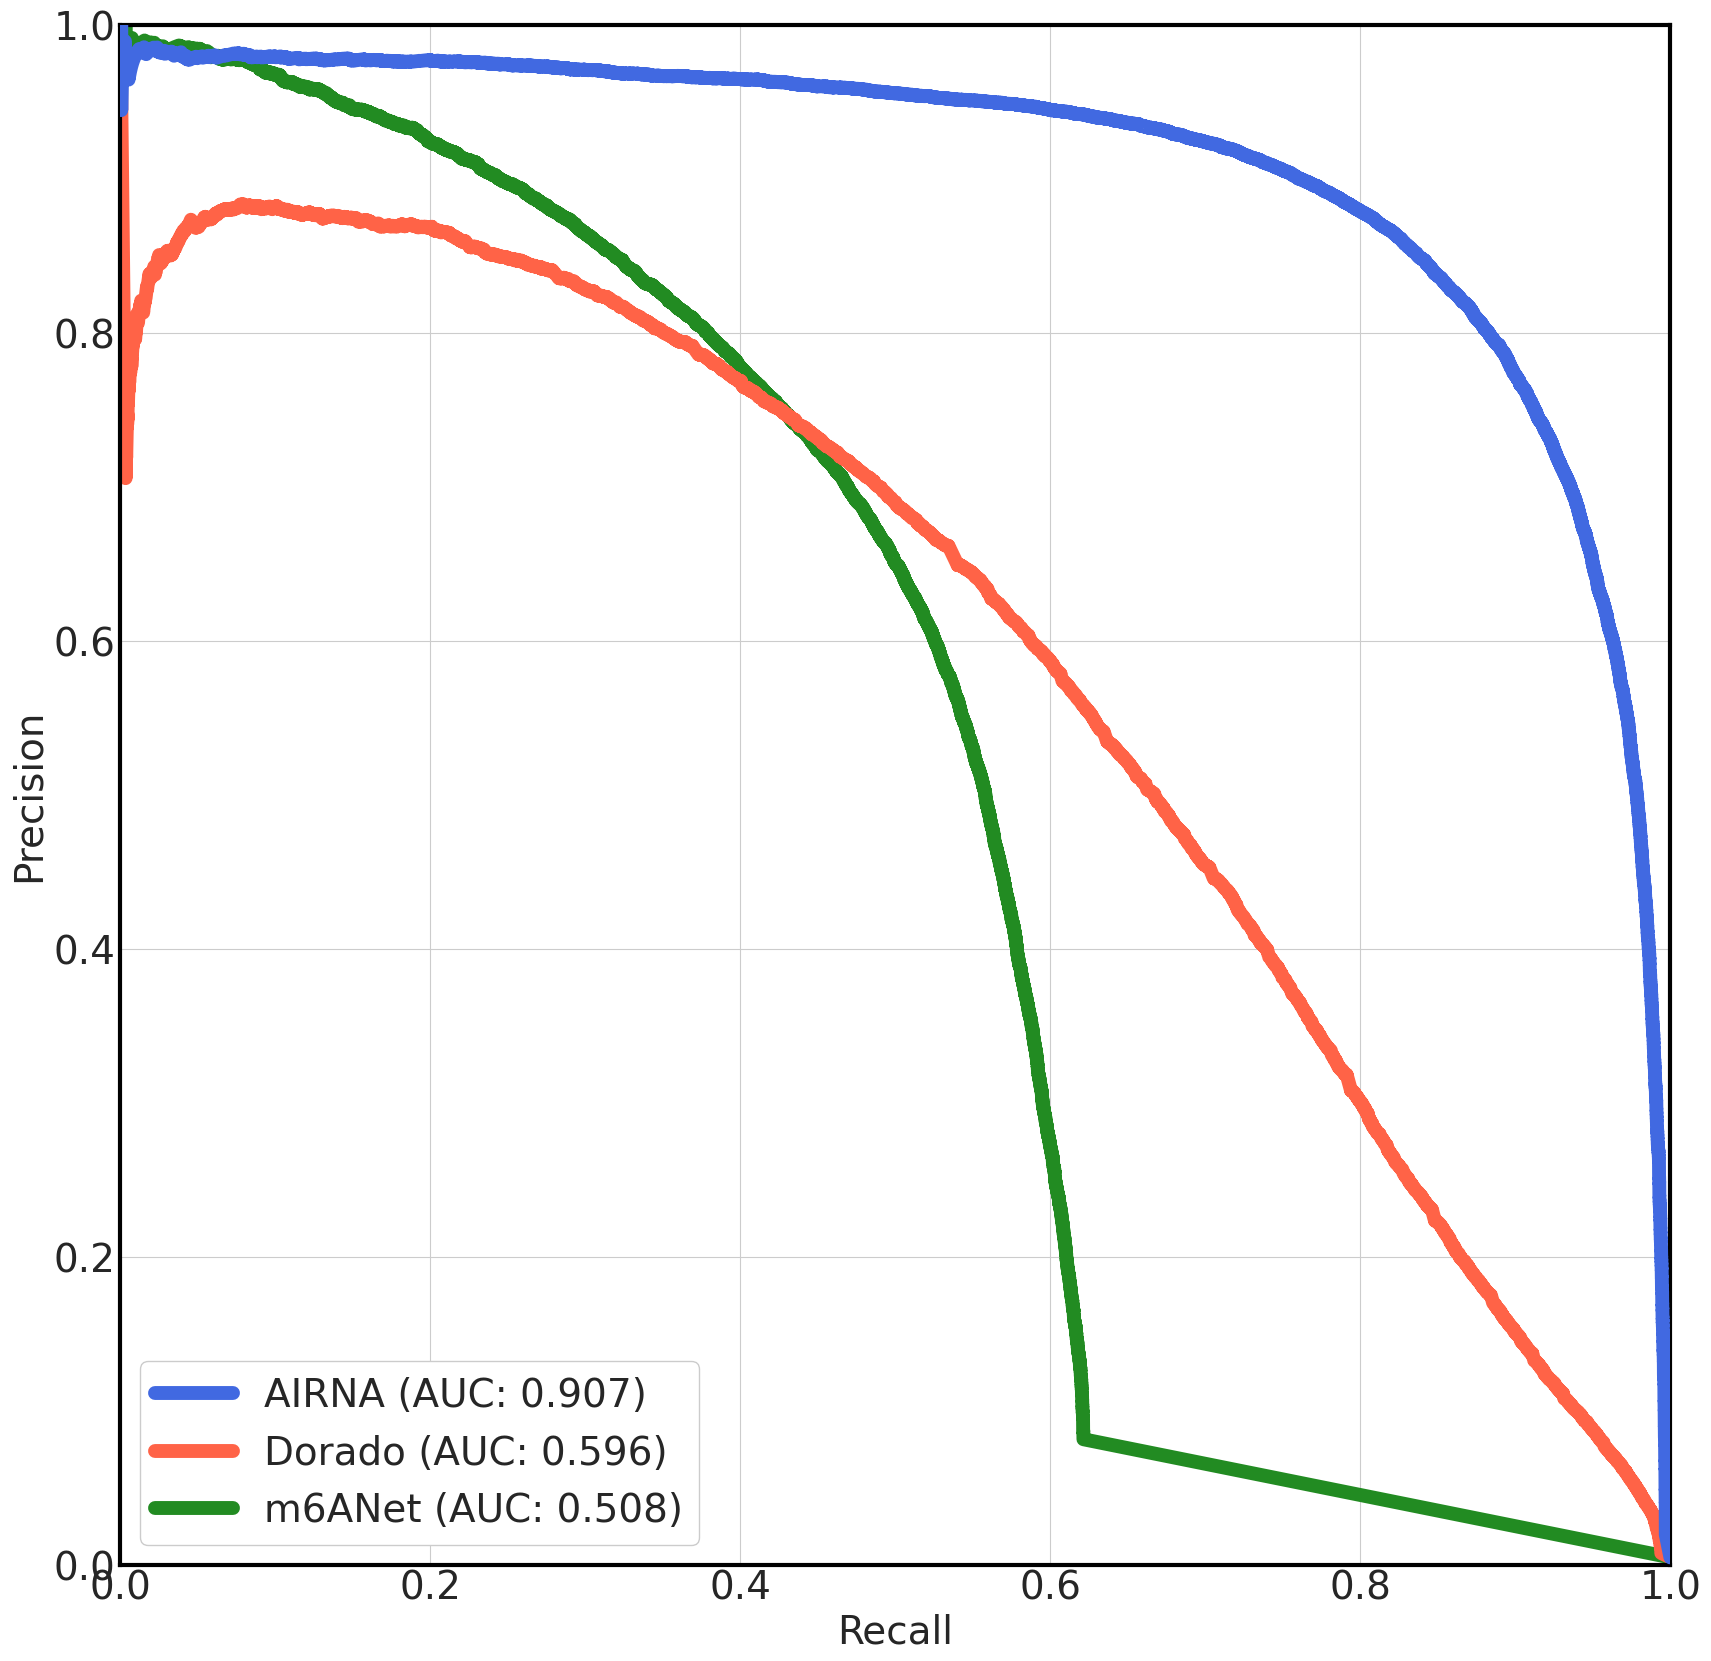

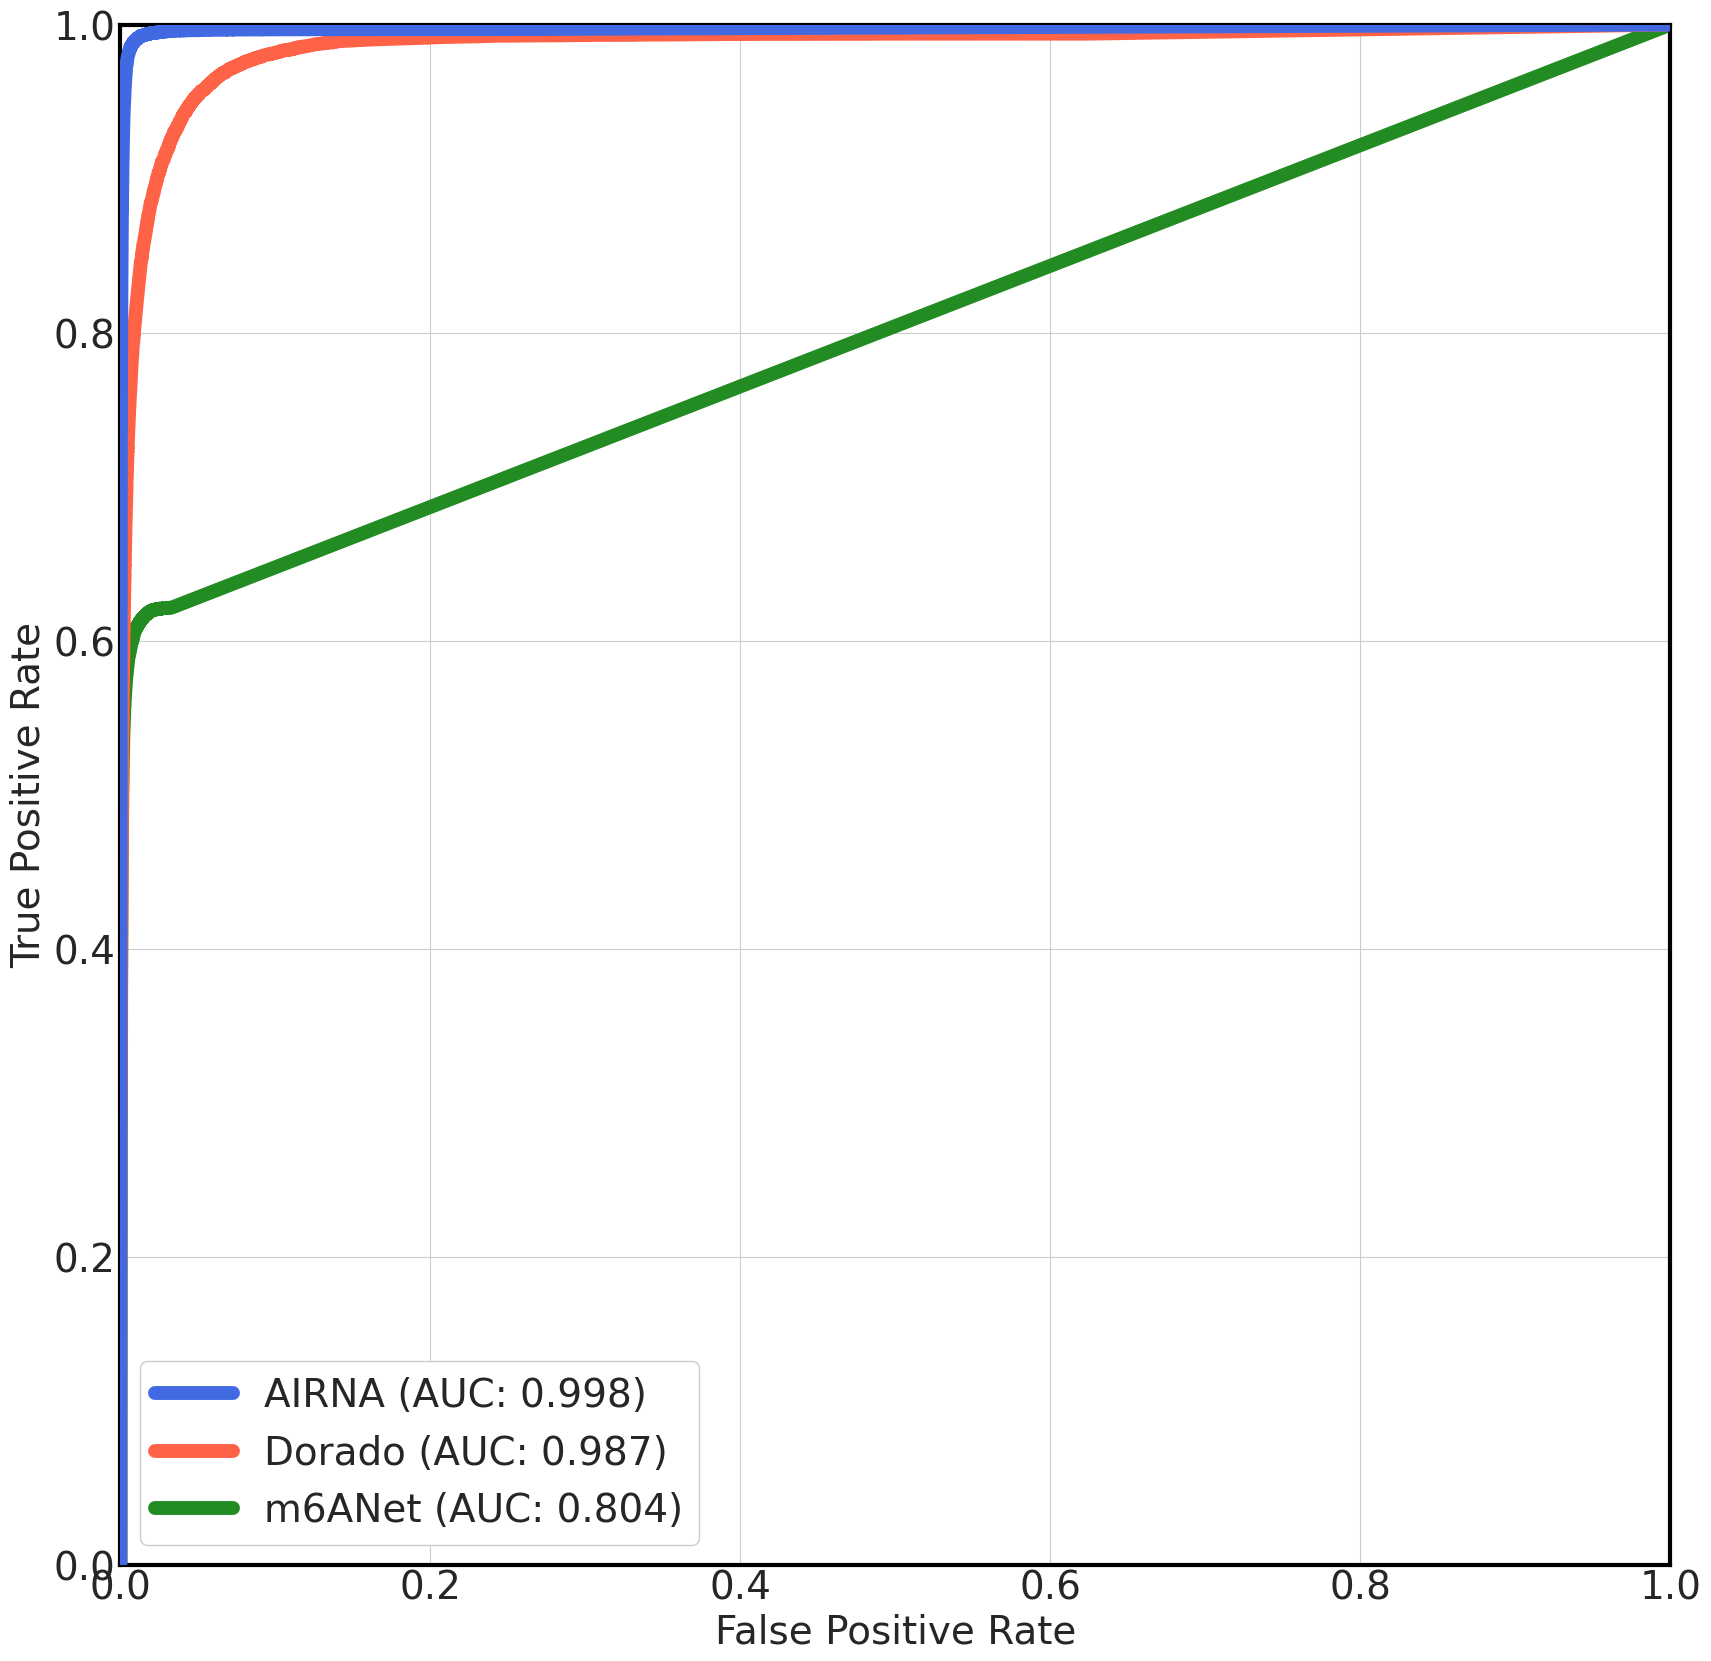

In [11]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

## Plot PR
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_roc.pdf", format="pdf")
plt.show()


In [12]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
print(selected_df)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.002955      482.0     0.004219   
1         chr10:+:1000683  0.008392  0.012536      488.0     0.004073   
2         chr10:+:1000685  0.007436  0.007190      488.0     0.017167   
4         chr10:+:1000701  0.016405  0.004825      486.0     0.002092   
5         chr10:+:1000704  0.024502  0.014842      492.0     0.036957   
...                   ...       ...       ...        ...          ...   
13247521  chrX:-:86047490  0.000000  0.000000       20.0     0.000000   
13247523  chrX:-:86047493  0.000000  0.000000       21.0     0.000000   
13247524  chrX:-:86047498  0.000000  0.000000       21.0     0.000000   
13247526  chrX:-:86047509  0.000000  0.000000       20.0     0.000000   
13247527  chrX:-:86047522  0.000000  0.000000        0.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                474.0     0.000000    0.000000

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.002955      482.0     0.004219   
2         chr10:+:1000685  0.007436  0.007190      488.0     0.017167   
5         chr10:+:1000704  0.024502  0.014842      492.0     0.036957   
6         chr10:+:1000713 -0.000000  0.000615      492.0     0.010183   
7         chr10:+:1000716  0.007680  0.003002      497.0     0.000000   
...                   ...       ...       ...        ...          ...   
13231569  chrX:-:77574324 -0.000000  0.006284       98.0     0.123457   
13231570  chrX:-:77574327 -0.000000  0.002007       99.0     0.011494   
13231572  chrX:-:77574334 -0.000000  0.001497       97.0     0.022727   
13231574  chrX:-:77574337  0.000000  0.000000       99.0     0.042553   
13231575  chrX:-:77574338 -0.000000  0.015018       99.0     0.011364   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                474.0          0.0         0.0

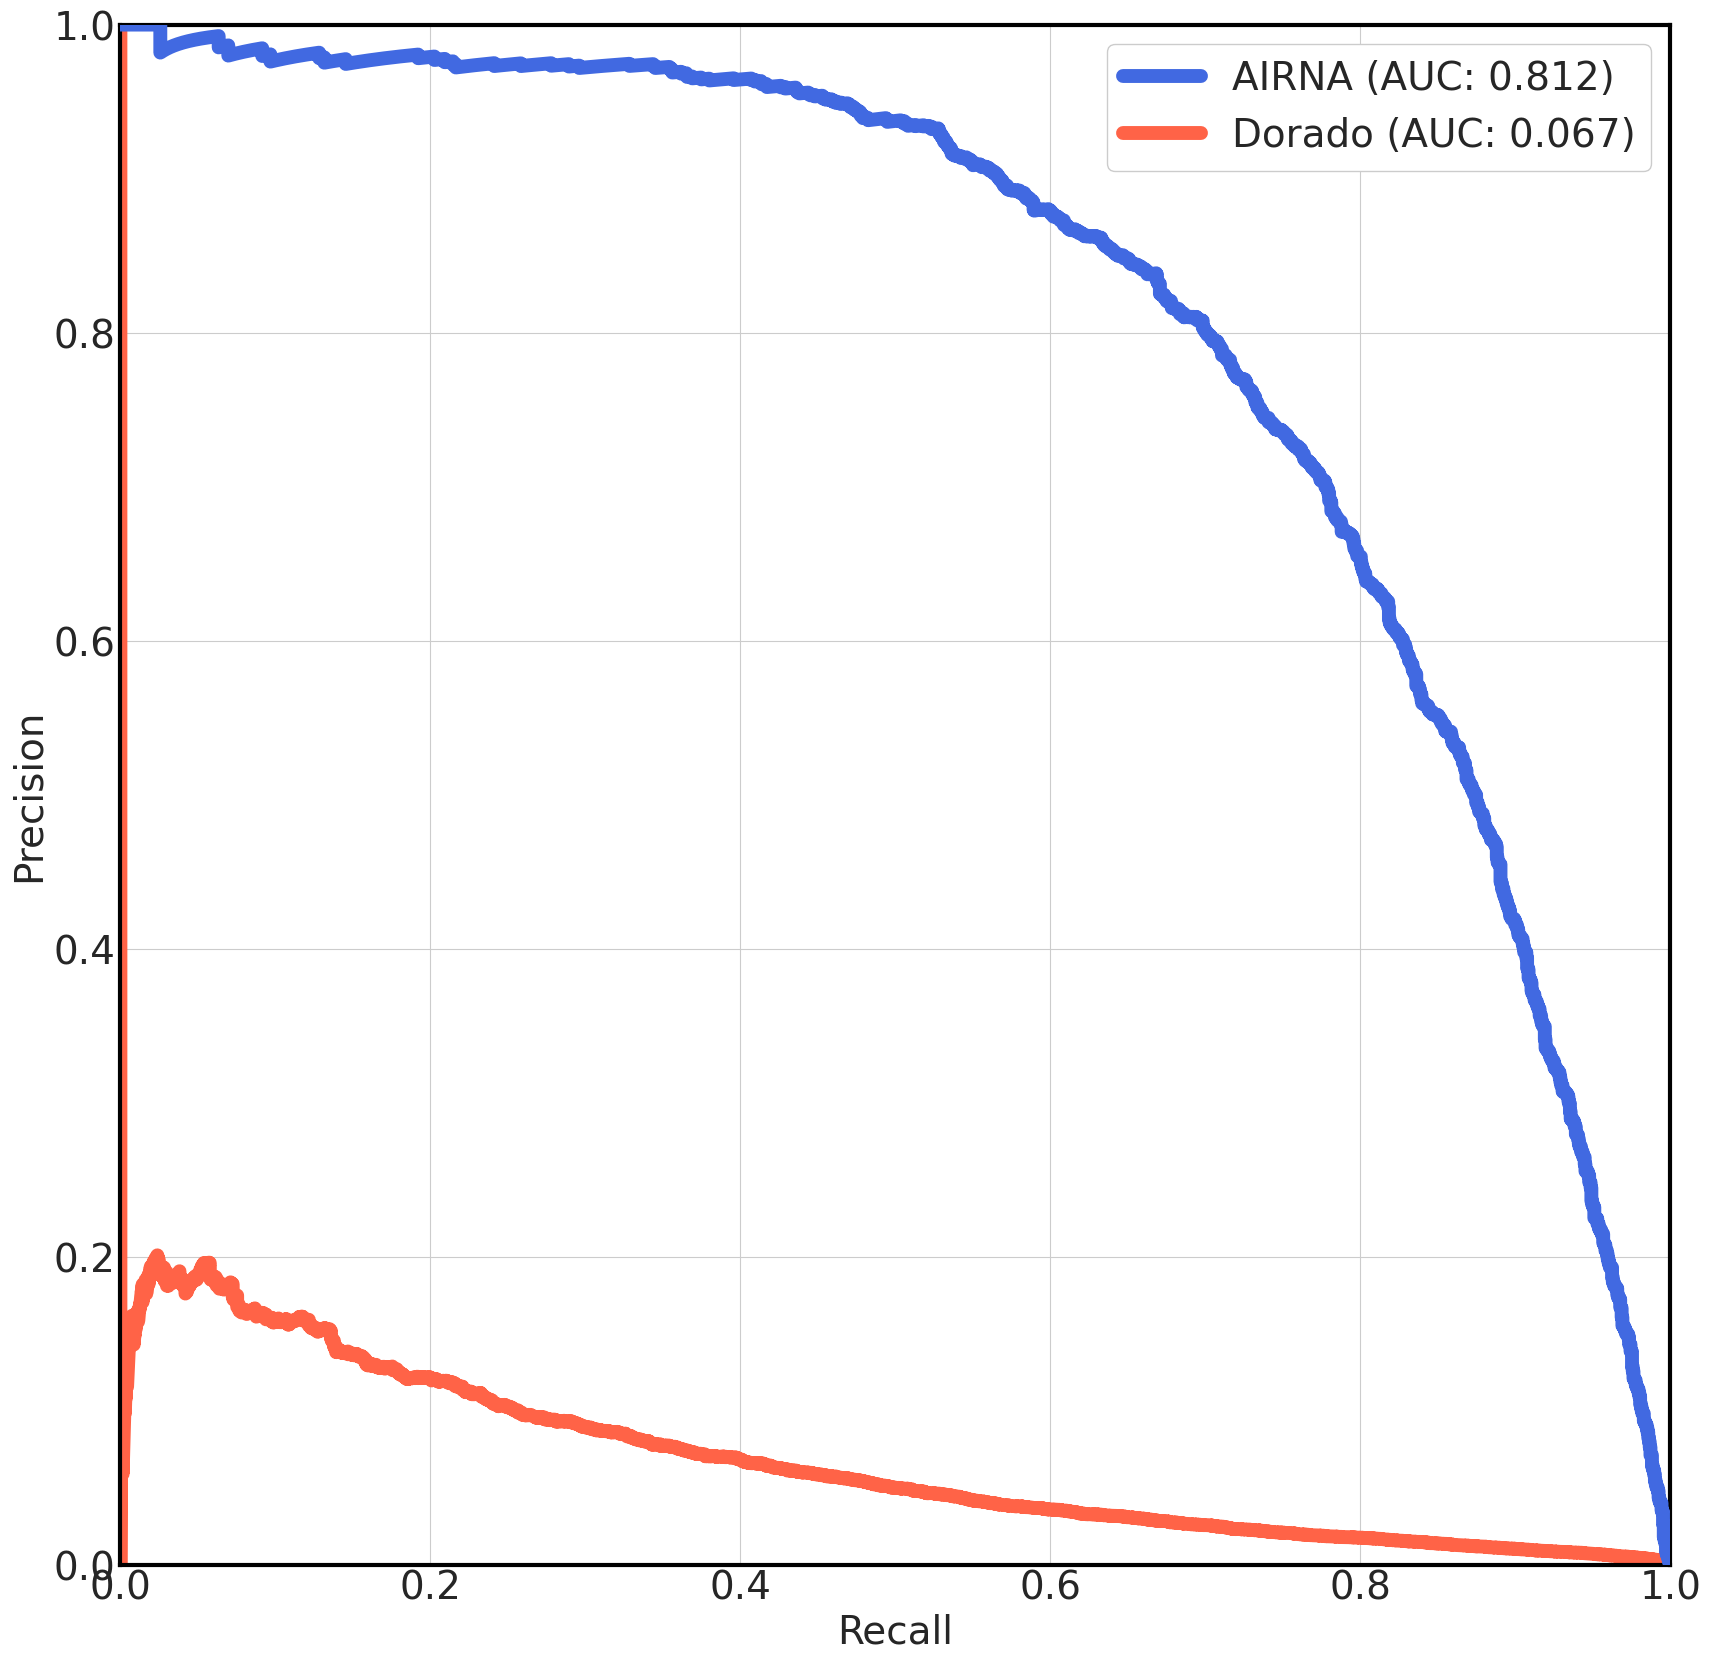

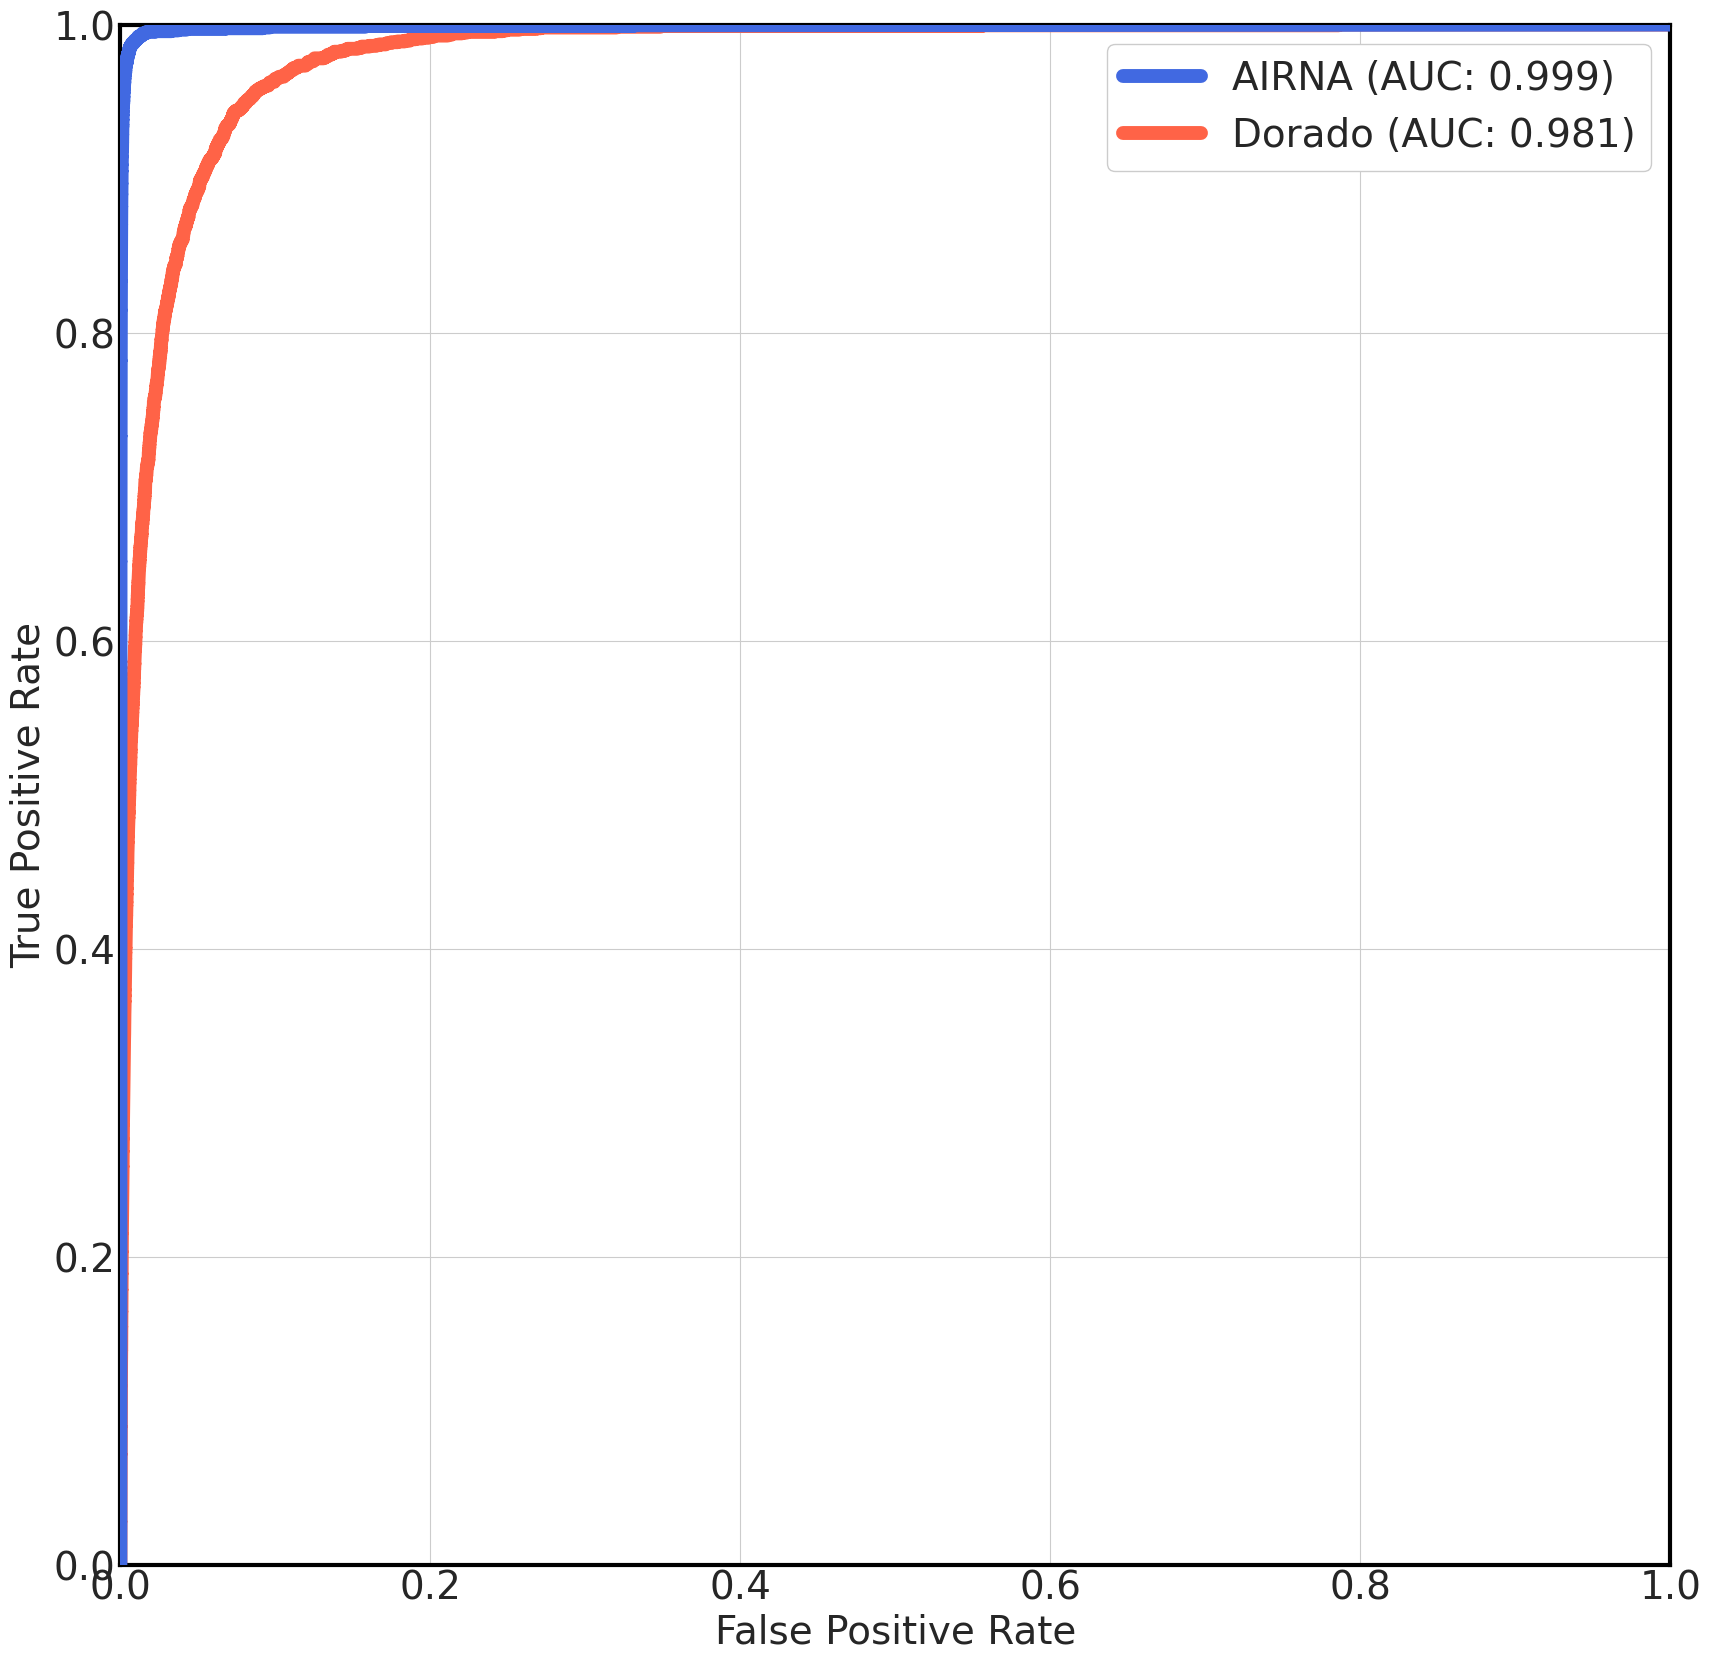

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = logsum_alt[~(logsum_alt["drach"]) & ((logsum_alt["depth"] >= 100)) & (logsum_alt["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

print(selected_df)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)


## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_roc.pdf", format="pdf")
plt.show()

                genome_id      pm6a       dom  count_all  pred_dorado  \
1         chr10:+:1000683  0.008392  0.012536      488.0     0.004073   
4         chr10:+:1000701  0.016405  0.004825      486.0     0.002092   
10        chr10:+:1000722  0.030743  0.008395      494.0     0.014463   
30        chr10:+:1000831  0.056227  0.022966      499.0     0.020492   
33        chr10:+:1000842  0.018723  0.016261      496.0     0.008658   
...                   ...       ...       ...        ...          ...   
13247474  chrX:-:85978868  0.180287  0.055522       20.0     0.000000   
13247478  chrX:-:85978880  0.000000  0.000000       20.0     0.040000   
13247480  chrX:-:85978886  0.000000  0.000000       20.0     0.000000   
13247492  chrX:-:85981763  0.000000  0.000000        0.0     0.000000   
13247496  chrX:-:85981788  0.000000  0.000000       21.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
1                491.0     0.114429    0.020225

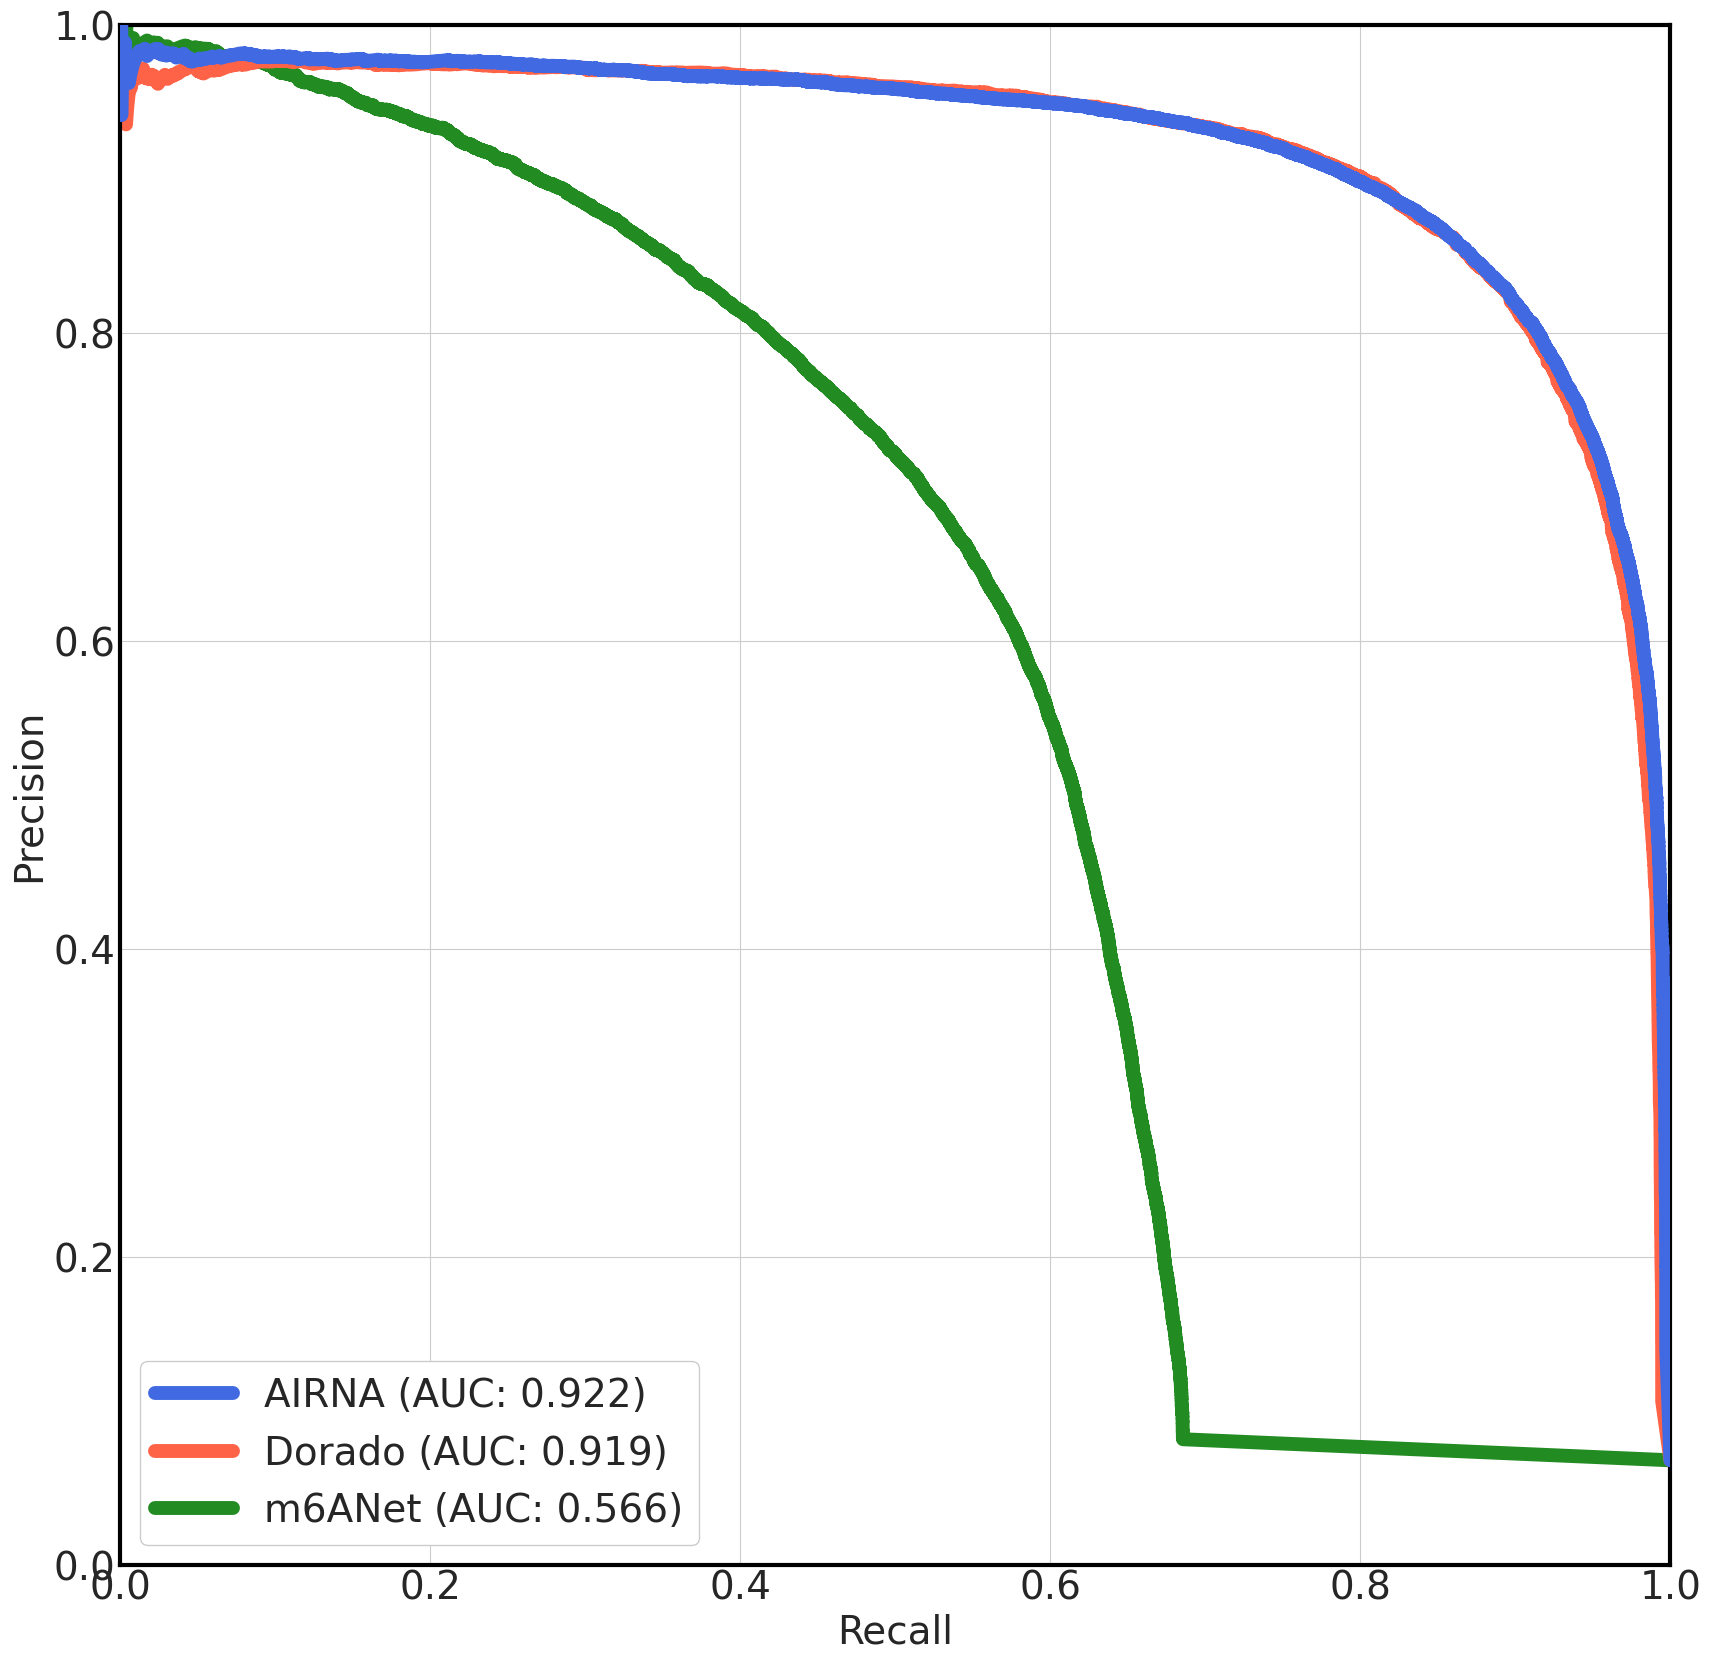

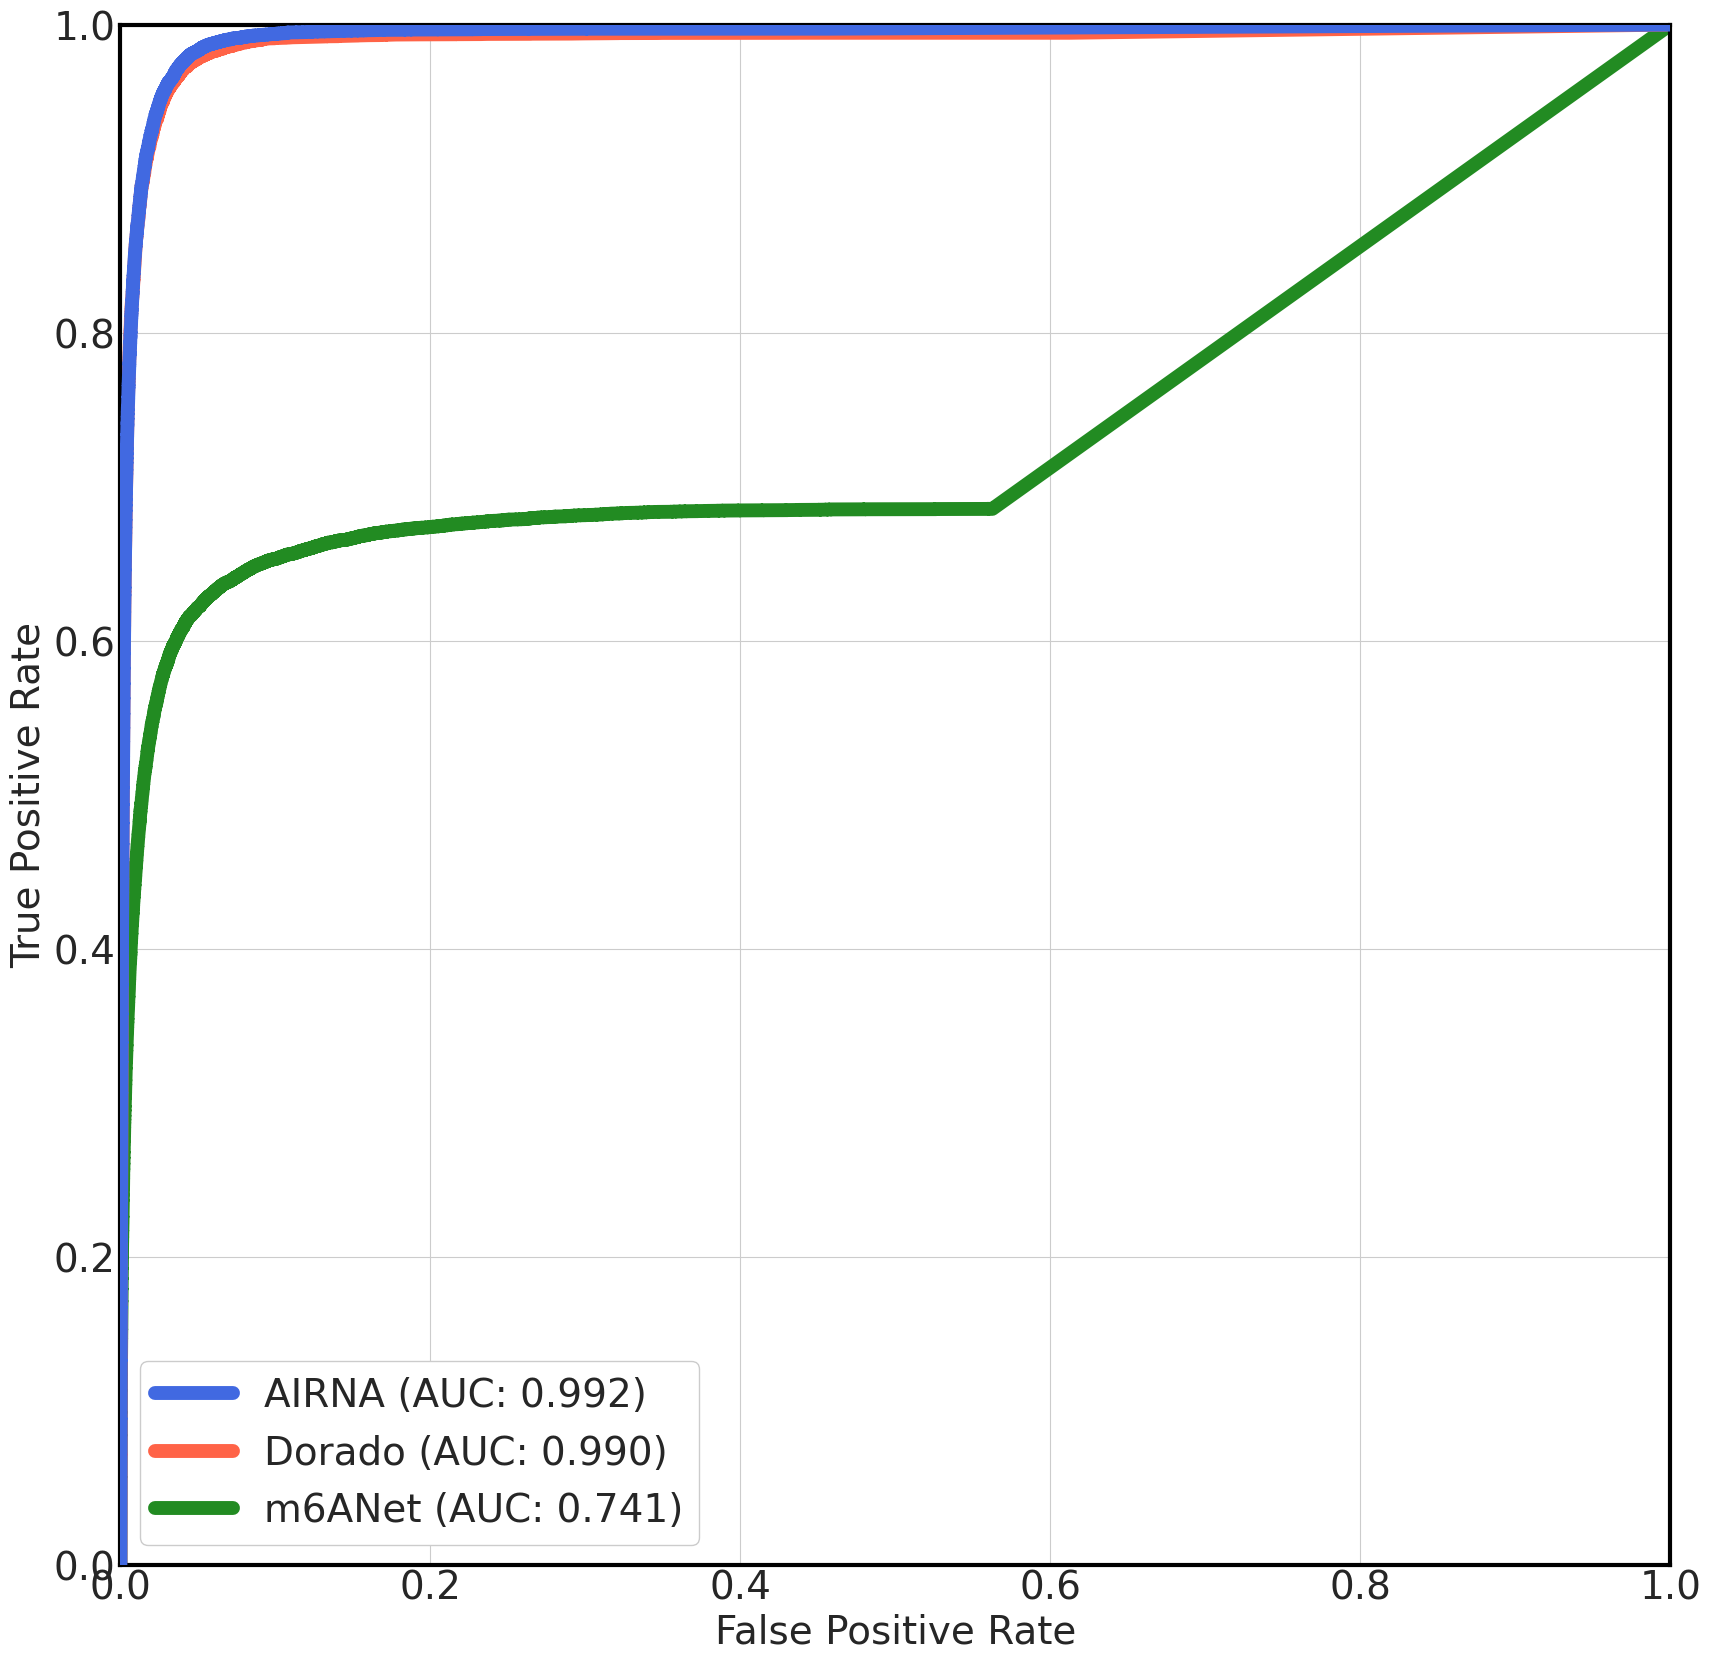

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = logsum_alt[(logsum_alt["drach"]) & (logsum_alt["label"] >= 0)& (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

print(selected_df)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_roc.pdf", format="pdf")
plt.show()


In [15]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}")

AIRNA Max F1: 0.844, Threshold: 0.899
Dorado Max F1: 0.594, Threshold: 0.460
m6Anet Max F1: 0.566, Threshold: 0.612


In [16]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1) 
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

AIRNA Max F1: 0.844, Threshold: 0.899, Recall: 0.842, Precision: 0.847
Dorado Max F1: 0.594, Threshold: 0.460, Recall: 0.578, Precision: 0.612
m6Anet Max F1: 0.566, Threshold: 0.612, Recall: 0.494, Precision: 0.662


In [17]:
from sklearn.metrics import accuracy_score

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

In [18]:
accuracy = accuracy_score(selected_df["label"], selected_df["pm6a"] > 0.869)
ppv = selected_df[selected_df["pm6a"] > 0.869]["label"].mean()
print(f"AIRNA Accuracy: {accuracy:.3f}, PPV: {ppv:.3f}")


AIRNA Accuracy: 0.999, PPV: 0.838


In [19]:
accuracy = accuracy_score(selected_df["label"], selected_df["pred_m6anet"] > 0.566)
ppv = selected_df[selected_df["pred_m6anet"] > 0.566]["label"].mean()
print(f"AIRNA Accuracy: {accuracy:.3f}, PPV: {ppv:.3f}")

AIRNA Accuracy: 0.996, PPV: 0.622
